# EIGSEP Recovery v003 — Canyon Joint Sky+Beam, with Terrain and a Ground Transmitter

The Marjum-canyon EIGSEP station rotates a science antenna through many
orientations over time. Three ingredients let us solve for the **sky** and the
**beam** jointly, and set the resolution at which the system is solvable:

1. **Terrain (the canyon horizon)** does double duty. It *masks* part of the
   sky, and — through its known ground emission `T_gnd` seen by the beam — it
   provides an **absolute flux reference** that breaks the sky×beam
   multiplicative degeneracy (the one that blocks a TX-free, terrain-free joint
   fit).
2. **Sidereal time sampling.** A single time is badly rank-deficient. Rotating
   the galactic sky through the fixed topocentric horizon over several sidereal
   times gives independent views, and the number of solvable sky modes grows
   with the number of times (the "hierarchy of intervals").
3. **A ground transmitter at nadir**, emitting in a few channels (e.g. every
   8th) with isolation in adjacent channels. As the antenna tumbles, the nadir
   sweeps a **2-D region** of the beam; differencing each TX channel against its
   smooth neighbours isolates the pure tone, giving a sharp, sky-independent,
   absolute probe of the beam *over that 2-D region* — an independent beam
   calibrator that sits on the terrain.

The forward model and solver prototype live in `benchmarks/canyon_tx_lib.py`
(validated against `ForwardModel.simulate` to machine precision). Conditional
solves (sky given beam; beam given sky, with TX folded in) are exact; both are
ill-posed, so we use a regularized eigen-basis (Wiener/Tikhonov) solve and
report the number of modes above the noise as the effective resolution.

In [1]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt
import healpy

sys.path.insert(0, os.path.abspath("../benchmarks"))
from canyon_tx_lib import (
    build_canyon, make_ops, sky_system, beam_system, eig_system, solve_reg,
    n_modes_above, map_err_sky, map_err_beam, chi2,
)
from canyon_tx_solve import make_data, solve_als
from eigsep_sim import Beam

plt.rcParams.update({"figure.dpi": 110})

# Live config: a few sidereal times x an az/alt orientation scan (kept modest
# so the notebook runs in a few minutes; the scaling study uses larger ones).
cfg = build_canyon(nside_sky=8, nside_beam=8, n_freq=24,
                   n_times=4, n_az=10, n_alt=6, tx_every=4, tx_power_K=1e5,
                   scan="tumble")
ops = make_ops(cfg)
print(f"orientations={cfg['n_orient']}  visible sky pix={int(cfg['sky_mask'].sum())}"
      f"  n_freq={cfg['n_freq']}  TX channels={list(np.where(cfg['tx_mask'])[0])}")

orientations=240  visible sky pix=511  n_freq=24  TX channels=[np.int64(0), np.int64(4), np.int64(8), np.int64(12), np.int64(16), np.int64(20)]


## 1. The transmitter sweeps a 2-D region of the beam

The hanging antenna spins about (roughly) vertical and swings about a fixed
horizontal axis, so azimuth is the **outer** rotation applied to an already
tilted body: `top2body = R_z(-az) R_x(-alt)`. The nadir `[0,0,-1]` then sweeps a
2-D cone on the beam as `(az, alt)` vary — `[-sin alt sin az, -sin alt cos az,
-cos alt]`. (Only if azimuth were the *inner* rotation about the vertical, with
nadir on that axis, would it collapse to a 1-D meridian.) So the transmitter is
a 2-D, sky-independent probe of the beam over the lower hemisphere. Below, the
red points are the actual nadir directions of the scan, on the body-frame beam.

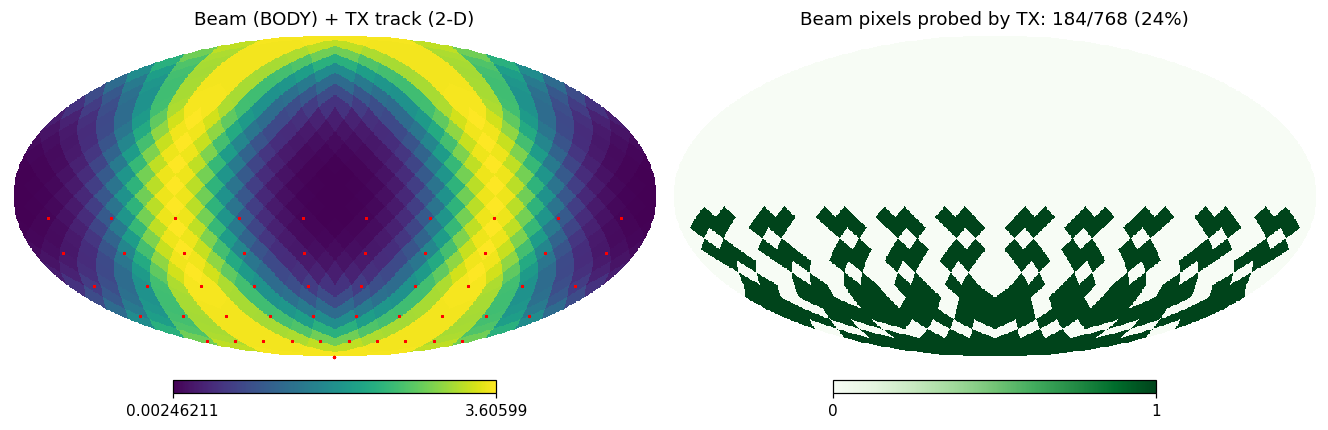

In [2]:
beam_mid = cfg["beam"].evaluate(cfg["n_freq"] // 2)[0]
# nadir direction in the body frame for every orientation in the scan
nadir = np.array([0, 0, -1.0])
body_rots = np.asarray(cfg["geom"]["body_rots_jax"])
tx_body = body_rots @ nadir            # (n_orient, 3)
th = np.arccos(np.clip(tx_body[:, 2], -1, 1)); ph = np.arctan2(tx_body[:, 1], tx_body[:, 0])
hit = np.unique(np.asarray(cfg["geom"]["tx_px_jax"])[:, :, 0])
cover = np.zeros(cfg["beam"].npix); cover[hit] = 1.0

fig = plt.figure(figsize=(12, 4))
healpy.mollview(beam_mid, fig=fig.number, sub=(1, 2, 1),
                title="Beam (BODY) + TX track (2-D)", cmap="viridis", hold=False)
healpy.projplot(th, ph, "r.", markersize=2)
healpy.mollview(cover, fig=fig.number, sub=(1, 2, 2), cmap="Greens",
                title=f"Beam pixels probed by TX: {len(hit)}/{cfg['beam'].npix} "
                      f"({100*len(hit)/cfg['beam'].npix:.0f}%)", hold=False)
plt.show()

## 2. Forward model and mock data

Terrain-masked, beam-weighted sky + terrain/ground emission + the TX tone in its
channels. The TX channels show up as bright stripes in the orientation×frequency
waterfall. We use a high-SNR mock dataset.

sigma=561  chi2/datum at truth=0.991


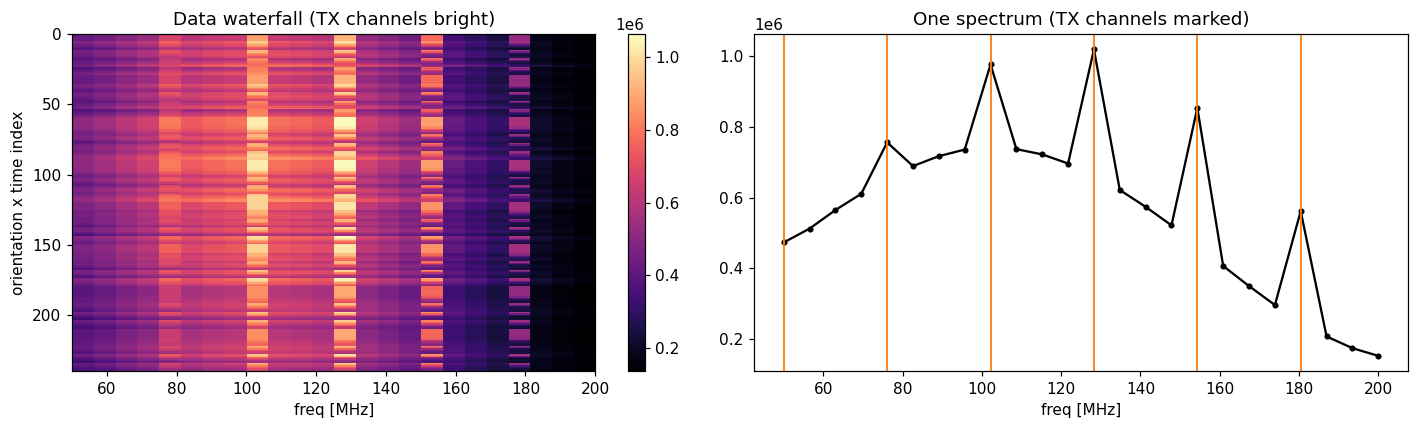

In [3]:
data, inv, sigma = make_data(cfg, ops, snr_frac=1e-3, seed=0)
fmhz = cfg["freqs"] / 1e6
print(f"sigma={sigma:.3g}  chi2/datum at truth="
      f"{chi2(ops, data, inv, cfg['sky_coeffs'], cfg['beam_coeffs']):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
im = ax[0].imshow(data, aspect="auto", interpolation="nearest",
                  extent=[fmhz[0], fmhz[-1], data.shape[0], 0], cmap="magma")
plt.colorbar(im, ax=ax[0]); ax[0].set_title("Data waterfall (TX channels bright)")
ax[0].set_xlabel("freq [MHz]"); ax[0].set_ylabel("orientation x time index")
ax[1].plot(fmhz, data[data.shape[0] // 2], "k.-")
for f in np.where(cfg["tx_mask"])[0]:
    ax[1].axvline(fmhz[f], color="C1", lw=1.2)
ax[1].set_title("One spectrum (TX channels marked)"); ax[1].set_xlabel("freq [MHz]")
plt.tight_layout(); plt.show()

## 3. Isolating the transmitter by differencing adjacent channels

The transmitter sits on top of the smooth sky+terrain emission. Because that
emission is smooth in frequency, a local fit to the neighbouring TX-free
channels extrapolates across the TX channel; subtracting it leaves the **pure TX
tone = beam × power**, sky-independent. The cleaner the separation, the brighter
the tone needs to be relative to the residual emission *curvature*; a calibration
tone is bright. The recovered TX signal then directly measures the beam over the
2-D region it sweeps — a sky-independent, absolute beam map (`beam_from_tx`).

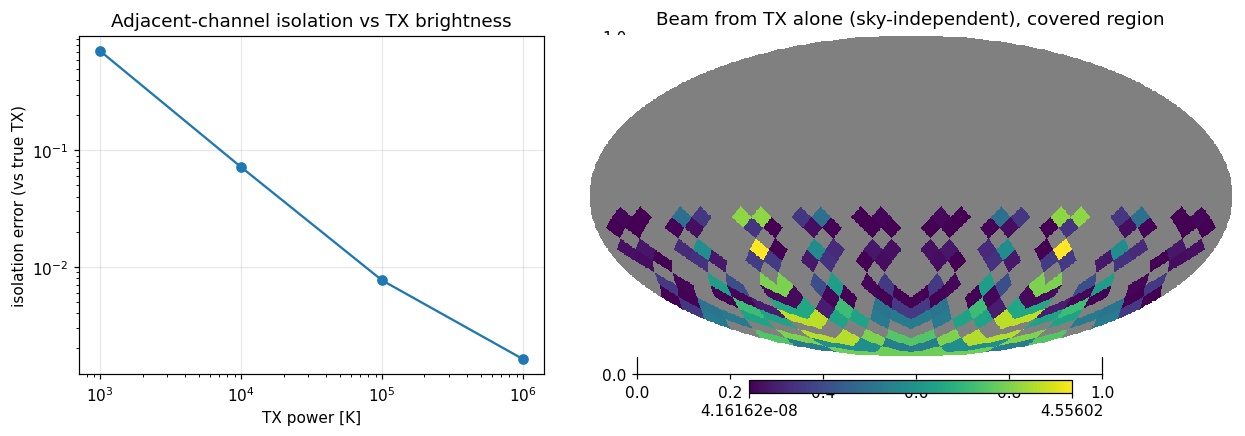

isolation error at P=1e5: 0.76%


In [4]:
from canyon_tx_lib import isolate_tx, beam_from_tx, map_err_beam
# isolation accuracy vs TX power (compare to the true TX term = sim_on - sim_off)
powers = [1e3, 1e4, 1e5, 1e6]
errs = []
for p in powers:
    cfgp = build_canyon(nside_sky=8, nside_beam=8, n_freq=24, n_times=4,
                        n_az=10, n_alt=6, tx_every=4, tx_power_K=p, scan="tumble")
    opsp = make_ops(cfgp); opsp_off = make_ops(cfgp, tx_on=False)
    dp, _, _ = make_data(cfgp, opsp, 1e-3, seed=0)
    tix = np.where(cfgp["tx_mask"])[0]
    true_tx = (np.asarray(opsp["simulate"](cfgp["sky_coeffs"], cfgp["beam_coeffs"]))
               - np.asarray(opsp_off["simulate"](cfgp["sky_coeffs"], cfgp["beam_coeffs"])))[:, tix]
    iso, _ = isolate_tx(cfgp, dp)
    errs.append(np.linalg.norm(iso - true_tx) / np.linalg.norm(true_tx))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].loglog(powers, errs, "o-"); ax[0].set_xlabel("TX power [K]")
ax[0].set_ylabel("isolation error (vs true TX)"); ax[0].grid(alpha=0.3)
ax[0].set_title("Adjacent-channel isolation vs TX brightness")
# beam-from-TX coverage at the live (bright) config
beam_tx, iso, tix = beam_from_tx(ops, cfg, data)
hit = np.unique(np.asarray(cfg["geom"]["tx_px_jax"])[:, :, 0])
bt = cfg["beam_coeffs"][0] @ cfg["beam"].basis.A.T
bf = np.asarray(beam_tx) @ cfg["beam"].basis.A.T
ch = cfg["n_freq"] // 2
cov = np.zeros(cfg["beam"].npix) * np.nan; cov[hit] = bf[hit, ch]
healpy.mollview(cov, sub=(1, 2, 2), fig=fig.number, cmap="viridis",
                title="Beam from TX alone (sky-independent), covered region", hold=False)
plt.show()
print(f"isolation error at P=1e5: {errs[2]*100:.2f}%")

## 4. What breaks the sky×beam scale degeneracy?

Scaling `(sky×s, beam/s)` leaves the bilinear sky term unchanged, so without an
absolute reference the scale `s` is unconstrained (the v001 degeneracy). The
curve below evaluates chi2 along that gauge for three cases. **No terrain → flat
(degenerate). Terrain → a sharp minimum at s=1**: the known ground emission is
an absolute reference. The transmitter adds to this (its strength grows with TX
power); its more distinctive role is robustness and beam *shape* (next sections).

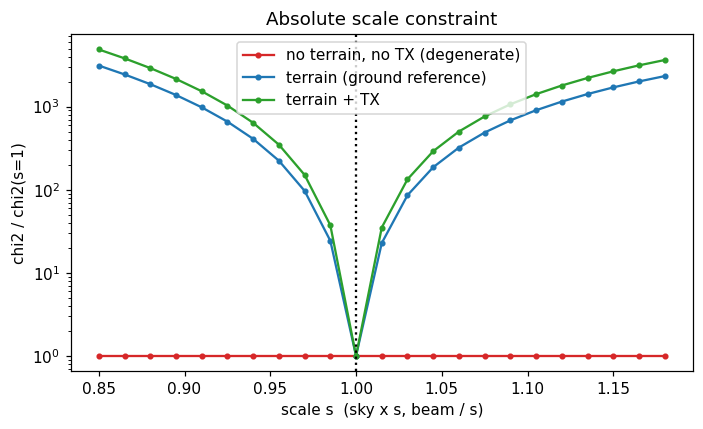

In [5]:
def scale_curve(cfg_, ops_, data_, inv_, ss):
    sc, bc = cfg_["sky_coeffs"], cfg_["beam_coeffs"]
    base = chi2(ops_, data_, inv_, sc, bc)
    return np.array([chi2(ops_, data_, inv_, sc * s, bc / s) / base for s in ss])

ss = np.linspace(0.85, 1.18, 23)
cfg_nt = build_canyon(nside_sky=8, nside_beam=8, n_freq=24, n_times=4,
                      n_az=8, n_alt=6, terrain=None)
ops_nt = make_ops(cfg_nt, tx_on=False)
d_nt, iv_nt, _ = make_data(cfg_nt, ops_nt, 1e-3)
ops_terr = make_ops(cfg, tx_on=False)
d_terr, iv_terr, _ = make_data(cfg, ops_terr, 1e-3)

plt.figure(figsize=(6.5, 4))
plt.plot(ss, scale_curve(cfg_nt, ops_nt, d_nt, iv_nt, ss), "C3-o", ms=3,
         label="no terrain, no TX (degenerate)")
plt.plot(ss, scale_curve(cfg, ops_terr, d_terr, iv_terr, ss), "C0-o", ms=3,
         label="terrain (ground reference)")
plt.plot(ss, scale_curve(cfg, ops, data, inv, ss), "C2-o", ms=3,
         label="terrain + TX")
plt.axvline(1.0, color="k", ls=":"); plt.yscale("log")
plt.xlabel("scale s  (sky x s, beam / s)"); plt.ylabel("chi2 / chi2(s=1)")
plt.title("Absolute scale constraint"); plt.legend(); plt.tight_layout(); plt.show()

## 5. Effective resolution: conditional eigenspectra

Each conditional problem is ill-posed. Eigendecomposing the normal-equations
Gram (given the true other parameter) shows a clear cutoff; the number of modes
above the noise floor is the effective number of solvable modes.

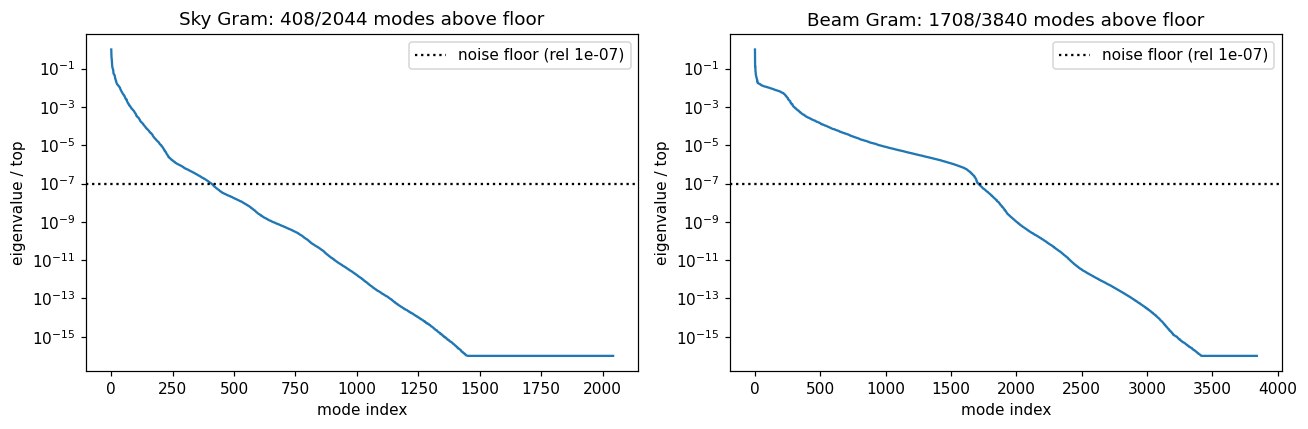

In [6]:
Hs, bs, P, Ms = sky_system(ops, cfg, data, inv, cfg["beam_coeffs"])
ws, _ = eig_system(Hs)
Hb, bb, prior, Q, Kb = beam_system(ops, cfg, data, inv, cfg["sky_coeffs"])
wb, _ = eig_system(Hb)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
floor = 1e-7
for a, w, ttl, n in [(ax[0], ws, "Sky Gram", P * Ms), (ax[1], wb, "Beam Gram", Q * Kb)]:
    a.semilogy(np.maximum(w / w[0], 1e-16), "C0-")
    a.axhline(floor, color="k", ls=":", label=f"noise floor (rel {floor:.0e})")
    a.set_title(f"{ttl}: {n_modes_above(w, floor*w[0])}/{n} modes above floor")
    a.set_xlabel("mode index"); a.set_ylabel("eigenvalue / top"); a.legend()
plt.tight_layout(); plt.show()

## 6. Resolution scaling (the interval hierarchy)

`benchmarks/canyon_tx_scaling.py` sweeps sidereal-time sampling and TX on/off
(oracle Wiener). **Sky resolution grows with sidereal time and requires
terrain**; **beam resolution grows with time and tilt diversity** and reaches
full rank with enough sampling (TX's conditional gain given a known sky is
small — its value is in the joint problem and in robustness).

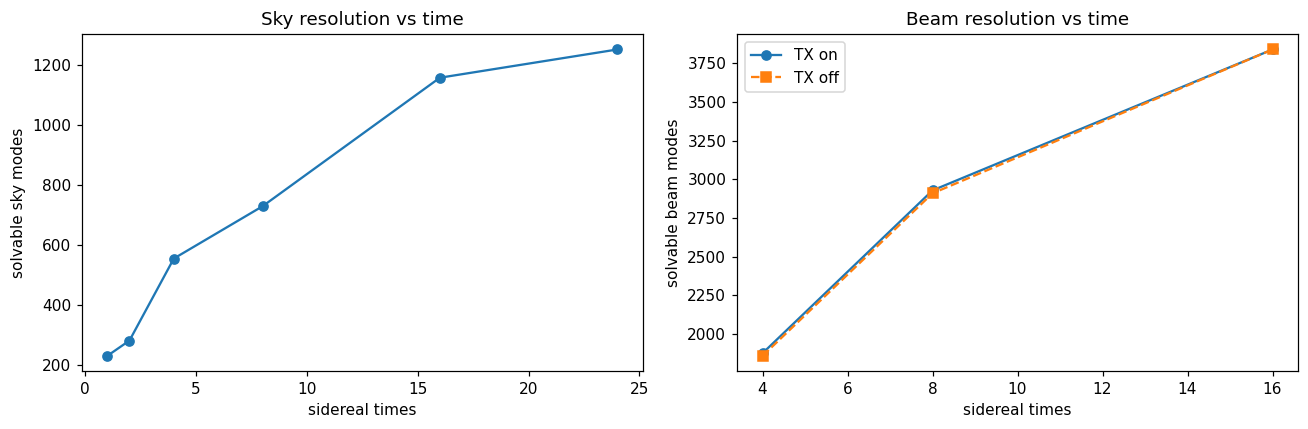

In [7]:
jp = "../benchmarks/results/canyon_tx_scaling.json"
if os.path.exists(jp):
    S = json.load(open(jp)); sky = S["sky"]; beam = S["beam"]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot([r["n_times"] for r in sky], [r["modes"] for r in sky], "o-")
    ax[0].set_xlabel("sidereal times"); ax[0].set_ylabel("solvable sky modes")
    ax[0].set_title("Sky resolution vs time")
    for tx, mk in [(True, "o-"), (False, "s--")]:
        pts = [r for r in beam if r["tx_on"] == tx]
        ax[1].plot([r["n_times"] for r in pts], [r["modes"] for r in pts], mk,
                   label=f"TX {'on' if tx else 'off'}")
    ax[1].set_xlabel("sidereal times"); ax[1].set_ylabel("solvable beam modes")
    ax[1].set_title("Beam resolution vs time"); ax[1].legend()
    plt.tight_layout(); plt.show()
else:
    print("Run: python benchmarks/canyon_tx_scaling.py 1e-3")

## 7. Joint recovery — regularized ALS

Both sky and beam start perturbed from truth. Alternating regularized exact
solves (sky given beam; beam given sky, TX folded in) is block coordinate
descent; the terrain reference fixes the scale and the regularization stabilizes
the ill-conditioned directions (the naive unregularized ALS diverges).

  round 0: chi2    0.575  sky_err 0.6458  beam_err 0.0891  dt 24.3s


  round 1: chi2    0.571  sky_err 0.5370  beam_err 0.0883  dt 24.3s


  round 2: chi2    0.571  sky_err 0.5122  beam_err 0.0897  dt 24.3s


  round 3: chi2    0.573  sky_err 0.5040  beam_err 0.0940  dt 24.3s


  round 4: chi2    0.573  sky_err 0.5028  beam_err 0.0954  dt 24.2s


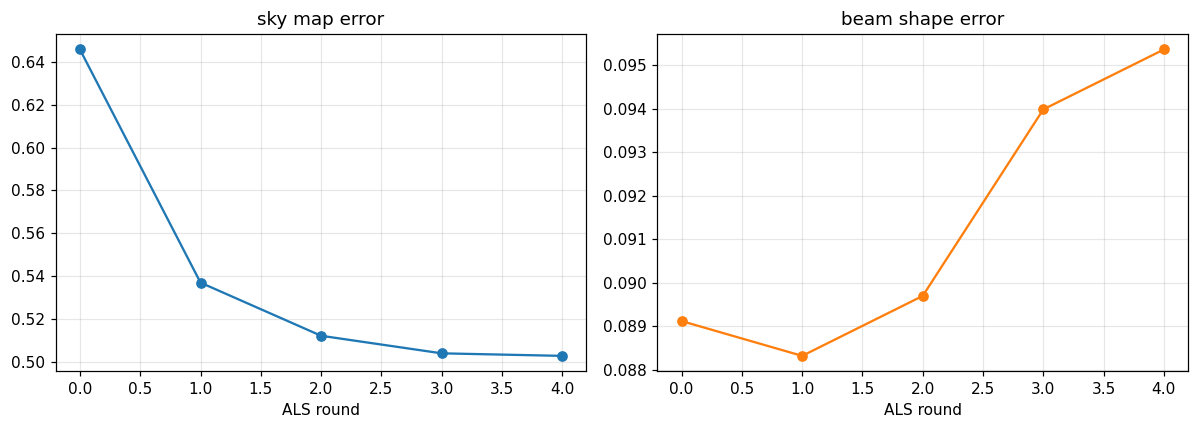

final: chi2 0.573  sky_err 0.503  beam_err 0.095


In [8]:
sky, beam, hist = solve_als(cfg, ops, data, inv, n_rounds=5, perturb=0.1,
                            lam_sky=3e-8, lam_beam=1e-7, verbose=True)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot([h["round"] for h in hist], [h["sky_err"] for h in hist], "C0o-")
ax[0].set_title("sky map error"); ax[0].set_xlabel("ALS round")
ax[1].plot([h["round"] for h in hist], [h["beam_err"] for h in hist], "C1o-")
ax[1].set_title("beam shape error"); ax[1].set_xlabel("ALS round")
for a in (ax): a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"final: chi2 {hist[-1]['chi2']:.3f}  sky_err {hist[-1]['sky_err']:.3f}  "
      f"beam_err {hist[-1]['beam_err']:.3f}")

## 8. Recovered maps

Recovered sky (galactic, visible pixels) and beam (body frame) vs truth from the
joint solve. The sky residual is dominated by the unconstrained small-scale
modes (the system is over-resolved at this nside/SNR — the solvable resolution
is the mode count from section 4-5, not the full nside).

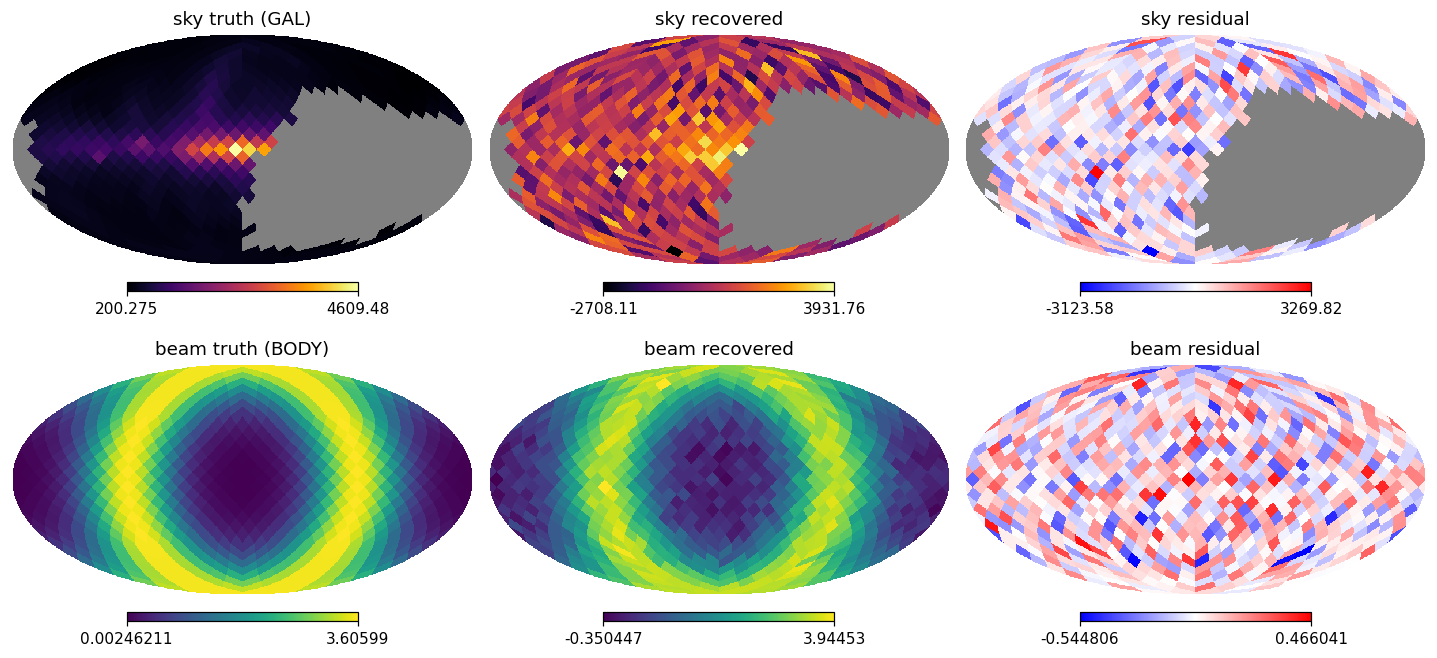

In [9]:
A_s = cfg["sky"].basis.A.T; A_b = cfg["beam"].basis.A.T
vis = np.asarray(cfg["sky_mask"]); ch = cfg["n_freq"] // 2
sky_t = cfg["sky_coeffs"] @ A_s; sky_f = np.asarray(sky) @ A_s
beam_t = cfg["beam_coeffs"][0] @ A_b; beam_f = np.asarray(beam) @ A_b
s = np.sum(beam_f * beam_t, 0) / np.maximum(np.sum(beam_f**2, 0), 1e-30)
beam_f = beam_f * s[None, :]
fig = plt.figure(figsize=(13, 6))
healpy.mollview(np.where(vis, sky_t[:, ch], np.nan), fig=fig.number, sub=(2, 3, 1),
                title="sky truth (GAL)", cmap="inferno", hold=False)
healpy.mollview(np.where(vis, sky_f[:, ch], np.nan), fig=fig.number, sub=(2, 3, 2),
                title="sky recovered", cmap="inferno", hold=False)
healpy.mollview(np.where(vis, sky_f[:, ch] - sky_t[:, ch], np.nan), fig=fig.number,
                sub=(2, 3, 3), title="sky residual", cmap="bwr", hold=False)
healpy.mollview(beam_t[:, ch], fig=fig.number, sub=(2, 3, 4), title="beam truth (BODY)",
                cmap="viridis", hold=False)
healpy.mollview(beam_f[:, ch], fig=fig.number, sub=(2, 3, 5), title="beam recovered",
                cmap="viridis", hold=False)
healpy.mollview(beam_f[:, ch] - beam_t[:, ch], fig=fig.number, sub=(2, 3, 6),
                title="beam residual", cmap="bwr", hold=False)
plt.show()

## Summary — the level at which the canyon system can be solved

- **Terrain is central**: it masks the sky (enabling resolution via time) *and*
  its known ground emission is the absolute flux reference that breaks the
  sky×beam scale degeneracy. Without it the scale is exactly degenerate.
- **Sky resolution is set by sidereal-time sampling**: solvable sky modes grow
  with the number of times (≈230 at 1 time → ≈1250 at 24 times here), the
  interval hierarchy the experiment naturally provides.
- **Beam resolution** grows with tilt diversity and time; with enough sampling
  the beam is fully solvable given the sky.
- **The transmitter** sweeps a **2-D region** of the beam as the antenna
  tumbles, and adjacent-channel differencing isolates its pure tone (clean once
  the tone is bright relative to the smooth-emission curvature). That makes it an
  independent, sky-independent, absolute beam *map* over the covered (lower)
  hemisphere — distinct from the terrain's diffuse ground reference, adding beam
  constraints and redundancy to the joint solve.
- The conditional problems are exact; the joint problem is solved by a
  regularized ALS. The effective resolution = number of Gram modes above the
  noise, which is the right figure of merit for "how high can we solve."

Code: `benchmarks/canyon_tx_lib.py` (model + solver),
`canyon_tx_{resolution,scaling,joint,degeneracy,power,tgnd}.py` (studies),
`canyon_tx_NOTES.md` (results log).